In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np

In [3]:
try:
    skel_dir = 'Y:/data/Eyewire2/morphologies-ew2/swc-final/2007c8b3d5870b8742b720823ceab1a0/9e713c5362f2535135fe15417bfec1fa'
    swc_files = [f for f in os.listdir(skel_dir) if f.endswith('.npz')]
except FileNotFoundError:
    skel_dir = '/gpfs01/berens/data/data/Eyewire2/morphologies-ew2/swc-final/2007c8b3d5870b8742b720823ceab1a0/9e713c5362f2535135fe15417bfec1fa'
    swc_files = [f for f in os.listdir(skel_dir) if f.endswith('.npz')]

print(len(swc_files))

1631


In [4]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../data/preprocessed-data"
nuc_col_master = "Updated Nuc ID\r\n(Oct 27)\r\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final NucID!"
seg_col_master = "Updated Seg ID\r\n(Oct 27)\r\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final SegID!"

df_merged = data_loader.load_df_rois_morph(
    morph_spreadsheet_filename = "Eyewire II Proofread Cells Master List - All Cells 2025-11-24.csv",
    morph_folder="../../data/morphological-data",
    data_folder="../../data/preprocessed-data",
    nuc_col_master=nuc_col_master,
    seg_col_master=seg_col_master,
)

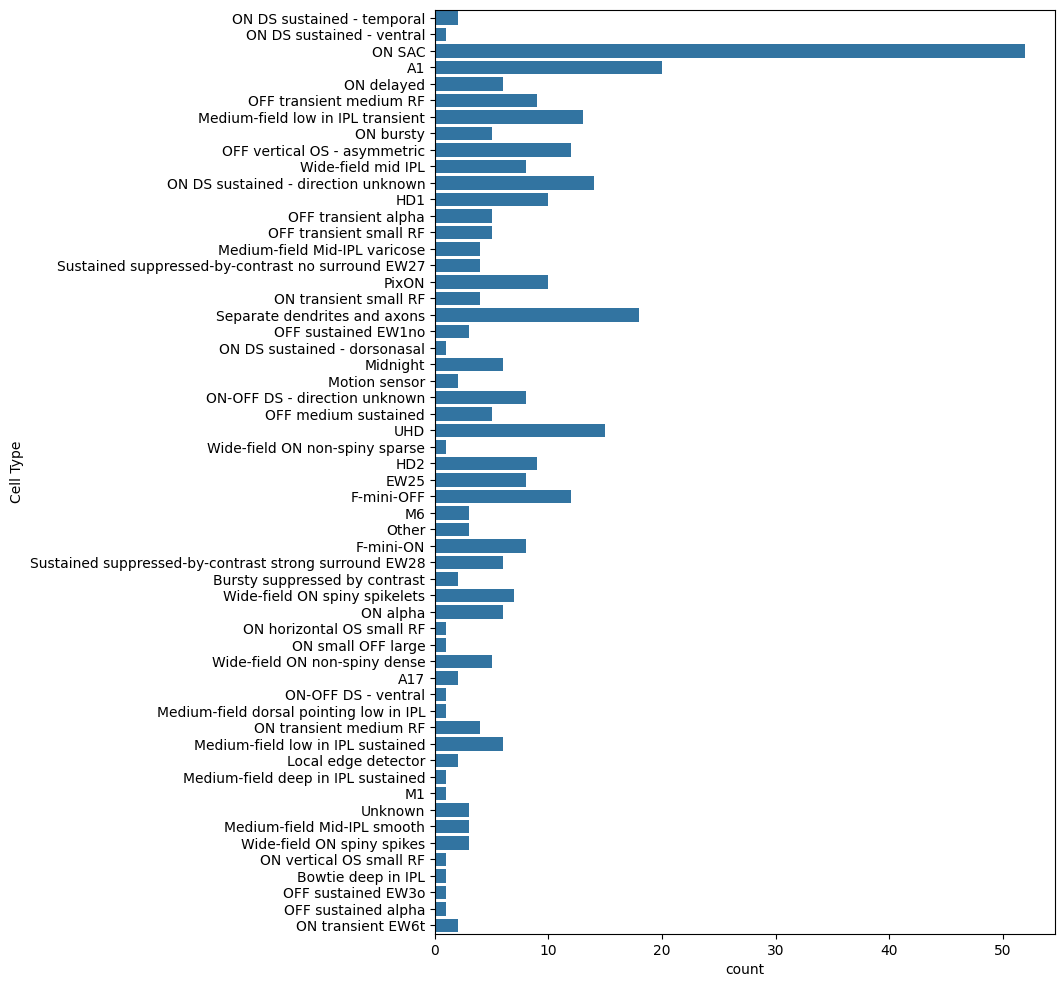

In [5]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df_merged, y='Cell Type')
plt.show()

In [6]:
from eyewire2_functional_analysis import plot
from eyewire2_functional_analysis.style import set_rc_params

set_rc_params(notebook_dpi=None)

In [7]:
def plot_cells(df):
    fig, axs = plt.subplots(len(df), 5, figsize=(6, len(df) * 0.8), width_ratios=(0.9, 0.5, 1.6, 1.6, 0.6))

    for i, ax_to_replace in enumerate(axs[:, -1]):
        ax_to_replace.remove()
        polar_ax = fig.add_subplot(ax_to_replace.get_subplotspec(), polar=True)
        axs[i, -1] = polar_ax

    all_xmin, all_xmax = [], []
    all_ymin, all_ymax = [], []
    
    for seg_id, row in df.iterrows():
        skel_rot = rotate_skel(row['skel'], rotation_deg=150)
    
        nodes = skel_rot.nodes[skel_rot.ntype == 3]
        nodes -= skel_rot.soma.center
        
        xmax, ymax, zmax = np.max(nodes, axis=0)
        xmin, ymin, zmin = np.min(nodes, axis=0)
    
        all_xmin.append(xmin)
        all_xmax.append(xmax)
        all_ymin.append(ymin)
        all_ymax.append(ymax)
    
    # Compute global limits with padding
    global_xlim = (min(all_xmin) - 13, max(all_xmax) + 3)
    global_ylim = (min(all_ymin) - 3, max(all_ymax) + 3)
    
    for i, (seg_id, row) in enumerate(df.iterrows()):
        ax = axs[i, 0]
        skel_rot = rotate_skel(row['skel'], rotation_deg=150)
        skel_rot.nodes -= skel_rot.soma.center

        sk.plot.projection(skel_rot,
                           ax=ax, xlim=global_ylim, ylim=global_xlim, plane='yx', draw_cylinders=False)
        plot.plot_scale_bar(ax=ax, x0=global_ylim[0] + 5, y0=np.mean(global_xlim),
                            size=100, text=False, unit='µm', tdist=0, orientation='v')
        ax.set_rasterized(True)

        ax = axs[i, 1]
        plot.plot_ipl_profile(ax=ax, row=row)

        ax = axs[i, 2]
        plot.plot_chirp(ax=ax, row=row)
        if i == (df.shape[0] - 1):
            plot.plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.05, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 3]
        plot.plot_bar(ax=ax, row=row, annotate_dirs=False, annotate_symbols=i == 0)
        if i == (df.shape[0] - 1):
            plot.plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.05, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 4]
        plot.plot_bar_dir(ax=ax, row=row)

    for ax in axs[:, :-1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax.axis('off')
        ax.set_facecolor((1, 1, 1, 0))

    plt.tight_layout(h_pad=0.5, w_pad=0.5)
    return fig, axs

In [8]:
from eyewire2_functional_analysis.skeleton import rotate_skel
import skeliner as sk


def add_skels(df):
    df = df.copy()
    df['swc_path'] = df[seg_col_master].apply(lambda x: os.path.join(skel_dir, f"{x}.npz"))
    df['swc_exists'] = df['swc_path'].apply(lambda x: os.path.isfile(x))
    if np.any(~df['swc_exists']):
        print('SWC not found:', df[~df['swc_exists']][seg_col_master].values)
    df = df[df['swc_exists']]
    df['skel'] = df['swc_path'].apply(lambda x: sk.io.load_npz(x))
    return df

SWC not found: ['720575940563641563']


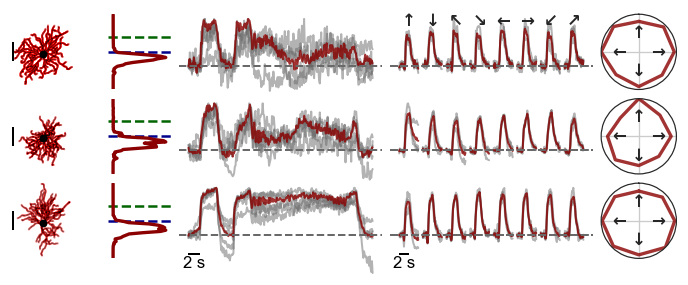

In [12]:
# https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5112165299126272

son_alpha_nuc_ids = [
    720575940557717614,
    720575940562274734,
    720575940562660177,
    720575940562905653,
]

df_type = add_skels(deepcopy(df_merged[
    (df_merged[nuc_col_master].astype(int).isin(son_alpha_nuc_ids))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
]))

if len(df_type) > 3:
    print('#' * 60)
    print('All')
    
    fig, axs = plot_cells(df_type)
    plt.show()
    
    print('#' * 60)
    print('Subset for figure')


fig, axs = plot_cells(df_type.iloc[:3])
plt.savefig('./figures/examples_son_alphas.svg', transparent=True, dpi=600)
plt.show()

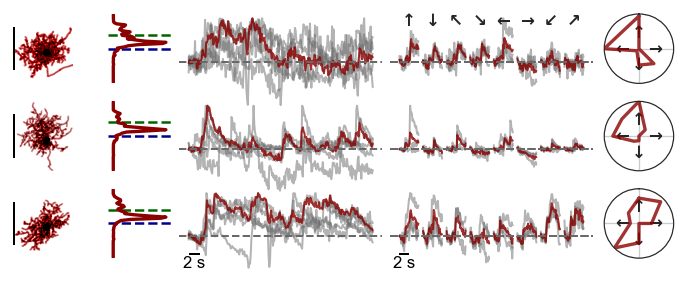

In [13]:
# https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5838312064417792

uhd_list = [
    720575940554823070,
    720575940555457712,
    720575940558194576
]

df_type = add_skels(deepcopy(df_merged[
    (df_merged[nuc_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
]))

if len(df_type) > 3:
    print('#' * 60)
    print('All')
    
    fig, axs = plot_cells(df_type)
    plt.show()
    
    print('#' * 60)
    print('Subset for figure')

fig, axs = plot_cells(df_type.iloc[:3])
plt.savefig('./figures/examples_uhd.svg', transparent=True, dpi=600)
plt.show()

############################################################
All


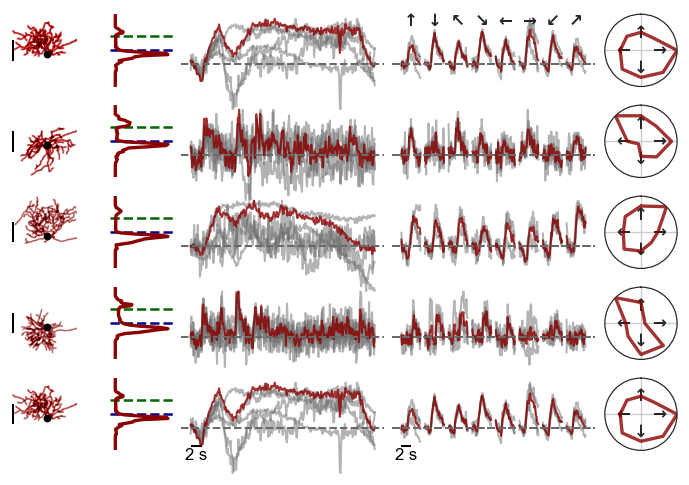

############################################################
Subset for figure


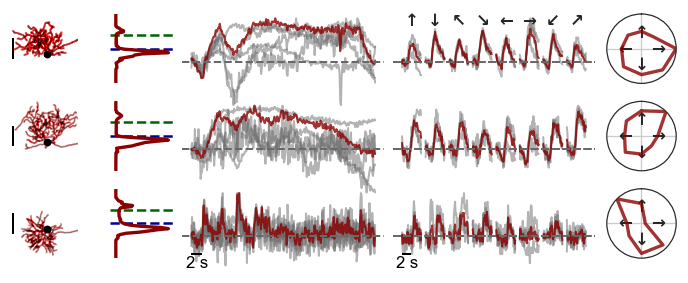

In [14]:
# https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5838312064417792

ds_seg_list = [
    720575940547915976,
    720575940550011222,
    720575940550605504,
    720575940554848042,
    720575940555722562,
    720575940559131851,
    720575940567685999,
    720575940570207675,
    720575940579841113,
]

df_type = add_skels(deepcopy(df_merged[
    (df_merged[seg_col_master].astype(int).isin(ds_seg_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
]))

if len(df_type) > 3:
    print('#' * 60)
    print('All')
    
    fig, axs = plot_cells(df_type)
    plt.show()
    
    print('#' * 60)
    print('Subset for figure')


fig, axs = plot_cells(df_type.iloc[[0, 2, 3]])
plt.savefig('./figures/examples_ds.svg', transparent=True, dpi=600)
plt.show()